In [1]:
# Setup and imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import pickle
import importlib
from scipy.spatial.distance import cdist

# Import orig_clases - vehicle classes we want to avoid
import consts
importlib.reload(consts)
orig_clases = consts.orig_clases

from aruco_pose import get_camera_angles_from_frame

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

print(f"Original vehicle classes to avoid: {orig_clases.tolist()}")
%matplotlib inline

c:\Users\danny\anaconda3\envs\py310\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Camera Matrix:
[[1.04739831e+03 0.00000000e+00 3.24036999e+02]
 [0.00000000e+00 9.50491793e+02 3.23897832e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients: [ 2.60138074e-01 -4.37871352e+00  3.56370583e-02 -2.58297180e-03
  2.21970709e+01]
Original vehicle classes to avoid: [817, 705, 609, 586, 436, 627, 468, 621, 803, 407, 408, 751, 717, 866, 661, 864]


In [48]:
# Load captured frames from both approaches
capaa_path = r"C:\git\PhysicalAdverserialProj\infer_caps_dir\capaa_jeep8_5_1\2025-12-24_22_31\caps.pkl"
best_patch_path = r"C:\git\PhysicalAdverserialProj\infer_caps_dir\best_patch_ensamble_classifier_16x16_7_2025-12-24_23_19\2025-12-24_23_22\caps.pkl"

with open(capaa_path, "rb") as f:
    caps_capaa = pickle.load(f)
print(f"CAPAA frames loaded: {len(caps_capaa)}")

with open(best_patch_path, "rb") as f:
    caps_best_patch = pickle.load(f)
print(f"Best Patch frames loaded: {len(caps_best_patch)}")

CAPAA frames loaded: 692
Best Patch frames loaded: 524


In [49]:
# Load all classifiers for evaluation
print("Loading classifiers...")

# Ensemble v1 classifier (Inception, ResNet, VGG, ViT, DINOv2)
import classfier_ensemble as ensemble_v1
ensemble_v1_weights = ensemble_v1.weights
print("✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)")

# Ensemble v2 classifier (ConvNeXt, EfficientNet, MobileNet, Swin)
import classfier_ensemble_v2 as ensemble_v2
ensemble_v2_weights = ensemble_v2.weights
print("✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)")

# DINOv2 standalone classifier
import classfier_dino as dino
dino_weights = dino.weights
print("✓ DINOv2 standalone classifier loaded")

categories = ensemble_v1_weights.meta["categories"]
print(f"\n✓ All classifiers ready for evaluation")

Loading classifiers...
✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)
✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)
✓ DINOv2 standalone classifier loaded

✓ All classifiers ready for evaluation


In [50]:
# Extract ArUco pose from all frames in both sets
def extract_poses(caps, name):
    """Extract ArUco poses from all frames."""
    poses = []
    for idx, frame in enumerate(tqdm(caps, desc=f"Extracting poses from {name}")):
        pose_result = get_camera_angles_from_frame(frame)
        if pose_result['found']:
            poses.append({
                'idx': idx,
                'angle': pose_result['angle'],
                'distance': pose_result['distance_m'],
                'frame': frame
            })
    return poses

poses_capaa = extract_poses(caps_capaa, "CAPAA")
poses_best_patch = extract_poses(caps_best_patch, "Best Patch")

print(f"\nCAPAA: {len(poses_capaa)} frames with ArUco detected")
print(f"Best Patch: {len(poses_best_patch)} frames with ArUco detected")

Extracting poses from Best Patch: 100%|██████████| 524/524 [00:00<00:00, 674.00it/s]


CAPAA: 325 frames with ArUco detected
Best Patch: 436 frames with ArUco detected


In [51]:
# Pair frames based on similar ArUco pose (angle and distance)
# Use nearest neighbor matching with a threshold

# Extract angle and distance arrays
capaa_poses = np.array([[p['angle'], p['distance']] for p in poses_capaa])
best_patch_poses = np.array([[p['angle'], p['distance']] for p in poses_best_patch])

# Normalize for distance calculation (angle range ~0-60, distance ~0.5-2m)
# Scale distance by 30 to make it comparable to angle
capaa_normalized = capaa_poses.copy()
capaa_normalized[:, 1] *= 30  # Scale distance
best_patch_normalized = best_patch_poses.copy()
best_patch_normalized[:, 1] *= 30

# Compute pairwise distances
distances = cdist(capaa_normalized, best_patch_normalized, metric='euclidean')

# Find best match for each CAPAA frame
POSE_THRESHOLD = 5.0  # Max allowed pose difference (in normalized units)

paired_frames = []
used_best_patch_indices = set()

for capaa_idx in range(len(poses_capaa)):
    # Find closest best_patch frame not yet used
    sorted_matches = np.argsort(distances[capaa_idx])
    for bp_idx in sorted_matches:
        if bp_idx not in used_best_patch_indices:
            dist = distances[capaa_idx, bp_idx]
            if dist < POSE_THRESHOLD:
                paired_frames.append({
                    'capaa': poses_capaa[capaa_idx],
                    'best_patch': poses_best_patch[bp_idx],
                    'pose_diff': dist,
                    'angle_diff': abs(poses_capaa[capaa_idx]['angle'] - poses_best_patch[bp_idx]['angle']),
                    'dist_diff': abs(poses_capaa[capaa_idx]['distance'] - poses_best_patch[bp_idx]['distance'])
                })
                used_best_patch_indices.add(bp_idx)
            break

print(f"\nTotal paired frames: {len(paired_frames)}")
print(f"Average angle difference: {np.mean([p['angle_diff'] for p in paired_frames]):.2f}°")
print(f"Average distance difference: {np.mean([p['dist_diff'] for p in paired_frames]):.3f}m")


Total paired frames: 277
Average angle difference: 1.29°
Average distance difference: 0.042m


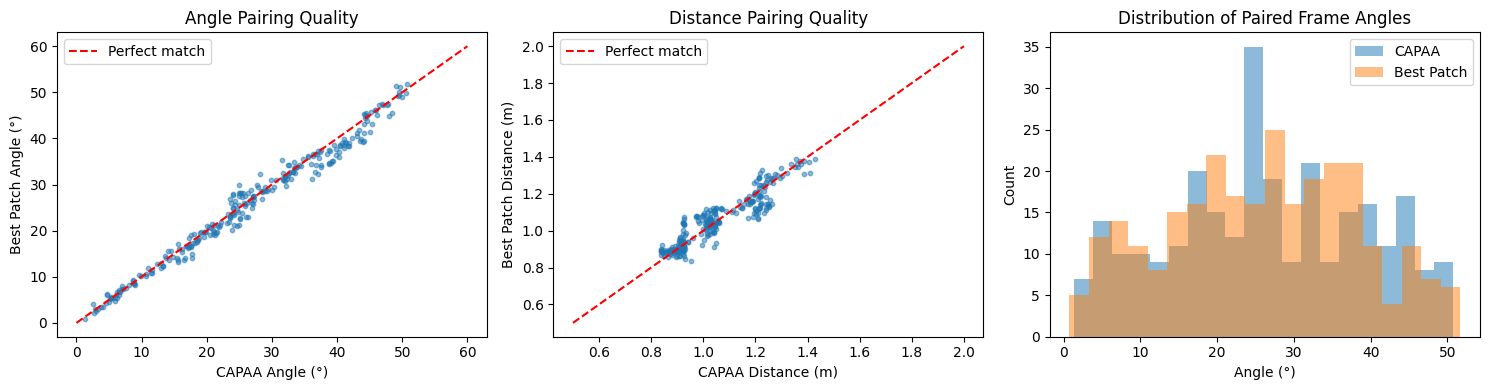

In [52]:
# Visualize the pairing quality
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Paired angles
ax = axes[0]
capaa_angles = [p['capaa']['angle'] for p in paired_frames]
bp_angles = [p['best_patch']['angle'] for p in paired_frames]
ax.scatter(capaa_angles, bp_angles, alpha=0.5, s=10)
ax.plot([0, 60], [0, 60], 'r--', label='Perfect match')
ax.set_xlabel('CAPAA Angle (°)')
ax.set_ylabel('Best Patch Angle (°)')
ax.set_title('Angle Pairing Quality')
ax.legend()

# Paired distances
ax = axes[1]
capaa_dists = [p['capaa']['distance'] for p in paired_frames]
bp_dists = [p['best_patch']['distance'] for p in paired_frames]
ax.scatter(capaa_dists, bp_dists, alpha=0.5, s=10)
ax.plot([0.5, 2], [0.5, 2], 'r--', label='Perfect match')
ax.set_xlabel('CAPAA Distance (m)')
ax.set_ylabel('Best Patch Distance (m)')
ax.set_title('Distance Pairing Quality')
ax.legend()

# Distribution of paired angles
ax = axes[2]
ax.hist(capaa_angles, bins=20, alpha=0.5, label='CAPAA')
ax.hist(bp_angles, bins=20, alpha=0.5, label='Best Patch')
ax.set_xlabel('Angle (°)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Paired Frame Angles')
ax.legend()

plt.tight_layout()
plt.show()

In [53]:
# Classify all paired frames with all models
results_list = []

for pair_idx, pair in enumerate(tqdm(paired_frames, desc="Classifying paired frames")):
    capaa_frame = pair['capaa']['frame']
    bp_frame = pair['best_patch']['frame']
    
    # Common pose info (use CAPAA as reference)
    angle = pair['capaa']['angle']
    distance = pair['capaa']['distance']
    
    # Prepare image tensors
    capaa_tensor = tt(capaa_frame).unsqueeze(0).cuda()
    bp_tensor = tt(bp_frame).unsqueeze(0).cuda()
    
    result_row = {
        'pair_idx': pair_idx,
        'angle_deg': angle,
        'distance_m': distance,
        'angle_diff': pair['angle_diff'],
        'dist_diff': pair['dist_diff'],
    }
    
    with torch.no_grad():
        # Get predictions for both approaches
        capaa_v1 = ensemble_v1.predict_raw_per_model(capaa_tensor)
        capaa_v2 = ensemble_v2.predict_raw_per_model(capaa_tensor)
        capaa_dino = dino.predict_raw(capaa_tensor)
        
        bp_v1 = ensemble_v1.predict_raw_per_model(bp_tensor)
        bp_v2 = ensemble_v2.predict_raw_per_model(bp_tensor)
        bp_dino = dino.predict_raw(bp_tensor)
    
    # Process V1 models
    for model_name in ['inception', 'resnet', 'vgg', 'vit', 'dino']:
        if model_name in capaa_v1:
            # CAPAA
            probs = capaa_v1[model_name]
            pred_idx = probs[0].argmax().item()
            is_success = pred_idx not in orig_clases.tolist()
            result_row[f'capaa_v1_{model_name}_success'] = is_success
            result_row[f'capaa_v1_{model_name}_class'] = categories[pred_idx]
            
            # Best Patch
            probs = bp_v1[model_name]
            pred_idx = probs[0].argmax().item()
            is_success = pred_idx not in orig_clases.tolist()
            result_row[f'bp_v1_{model_name}_success'] = is_success
            result_row[f'bp_v1_{model_name}_class'] = categories[pred_idx]
    
    # V1 Combined
    if 'ensemble' in capaa_v1:
        pred_idx = capaa_v1['ensemble'][0].argmax().item()
        result_row['capaa_v1_combined_success'] = pred_idx not in orig_clases.tolist()
        result_row['capaa_v1_combined_class'] = categories[pred_idx]
        
        pred_idx = bp_v1['ensemble'][0].argmax().item()
        result_row['bp_v1_combined_success'] = pred_idx not in orig_clases.tolist()
        result_row['bp_v1_combined_class'] = categories[pred_idx]
    
    # Process V2 models
    for model_name in ['convnext', 'efficientnet', 'mobilenet', 'swin']:
        if model_name in capaa_v2:
            # CAPAA
            probs = capaa_v2[model_name]
            pred_idx = probs[0].argmax().item()
            is_success = pred_idx not in orig_clases.tolist()
            result_row[f'capaa_v2_{model_name}_success'] = is_success
            result_row[f'capaa_v2_{model_name}_class'] = categories[pred_idx]
            
            # Best Patch
            probs = bp_v2[model_name]
            pred_idx = probs[0].argmax().item()
            is_success = pred_idx not in orig_clases.tolist()
            result_row[f'bp_v2_{model_name}_success'] = is_success
            result_row[f'bp_v2_{model_name}_class'] = categories[pred_idx]
    
    # V2 Combined
    if 'ensemble' in capaa_v2:
        pred_idx = capaa_v2['ensemble'][0].argmax().item()
        result_row['capaa_v2_combined_success'] = pred_idx not in orig_clases.tolist()
        result_row['capaa_v2_combined_class'] = categories[pred_idx]
        
        pred_idx = bp_v2['ensemble'][0].argmax().item()
        result_row['bp_v2_combined_success'] = pred_idx not in orig_clases.tolist()
        result_row['bp_v2_combined_class'] = categories[pred_idx]
    
    # DINOv2 standalone
    pred_idx = capaa_dino[0].argmax().item()
    result_row['capaa_dino_success'] = pred_idx not in orig_clases.tolist()
    result_row['capaa_dino_class'] = categories[pred_idx]
    
    pred_idx = bp_dino[0].argmax().item()
    result_row['bp_dino_success'] = pred_idx not in orig_clases.tolist()
    result_row['bp_dino_class'] = categories[pred_idx]
    
    results_list.append(result_row)

df = pd.DataFrame(results_list)
print(f"\n✓ Analyzed {len(df)} paired frames")

Classifying paired frames: 100%|██████████| 277/277 [00:54<00:00,  5.10it/s]


✓ Analyzed 277 paired frames


## Table 1: Ensemble V1 Models Comparison

In [62]:
# Table 1: V1 Models Comparison
v1_models = ['inception', 'resnet', 'vgg', 'vit','combined']
v1_display = ['Inception V3', 'ResNet18', 'VGG16', 'ViT-B/16', 'COMBINED']

v1_comparison = []
for model, display in zip(v1_models, v1_display):
    capaa_col = f'capaa_v1_{model}_success'
    bp_col = f'bp_v1_{model}_success'
    
    if capaa_col in df.columns and bp_col in df.columns:
        capaa_rate = df[capaa_col].mean() * 100
        bp_rate = df[bp_col].mean() * 100
        diff = capaa_rate - bp_rate
        
        v1_comparison.append({
            'Model': display,
            'CAPAA (%)': f"{capaa_rate:.1f}",
            'Best Patch (%)': f"{bp_rate:.1f}",
            'Difference': f"{diff:+.1f}",
            'Winner': 'CAPAA' if diff > 0 else ('Best Patch' if diff < 0 else 'Tie')
        })

v1_df = pd.DataFrame(v1_comparison)
print("="*80)
print("TABLE 1: ENSEMBLE V1 MODELS (Inception V3, ResNet18, VGG16, ViT-B/16)")
print("="*80)
print(v1_df.to_string(index=False))
print()

TABLE 1: ENSEMBLE V1 MODELS (Inception V3, ResNet18, VGG16, ViT-B/16)
       Model CAPAA (%) Best Patch (%) Difference     Winner
Inception V3      42.2           88.8      -46.6 Best Patch
    ResNet18      91.7           94.2       -2.5 Best Patch
       VGG16      96.0           86.6       +9.4      CAPAA
    ViT-B/16      82.3           96.4      -14.1 Best Patch
    COMBINED      86.3           97.1      -10.8 Best Patch



## Table 2: Ensemble V2 Models Comparison

In [63]:
# Table 2: V2 Models Comparison
v2_models = ['convnext', 'efficientnet', 'mobilenet', 'swin', 'combined']
v2_display = ['ConvNeXt Base', 'EfficientNet B0', 'MobileNetV3 Large', 'Swin Transformer', 'COMBINED']

v2_comparison = []
for model, display in zip(v2_models, v2_display):
    capaa_col = f'capaa_v2_{model}_success'
    bp_col = f'bp_v2_{model}_success'
    
    if capaa_col in df.columns and bp_col in df.columns:
        capaa_rate = df[capaa_col].mean() * 100
        bp_rate = df[bp_col].mean() * 100
        diff = capaa_rate - bp_rate
        
        v2_comparison.append({
            'Model': display,
            'CAPAA (%)': f"{capaa_rate:.1f}",
            'Best Patch (%)': f"{bp_rate:.1f}",
            'Difference': f"{diff:+.1f}",
            'Winner': 'CAPAA' if diff > 0 else ('Best Patch' if diff < 0 else 'Tie')
        })

v2_df = pd.DataFrame(v2_comparison)
print("="*80)
print("TABLE 2: ENSEMBLE V2 MODELS (ConvNeXt, EfficientNet, MobileNet, Swin)")
print("="*80)
print(v2_df.to_string(index=False))
print()

TABLE 2: ENSEMBLE V2 MODELS (ConvNeXt, EfficientNet, MobileNet, Swin)
            Model CAPAA (%) Best Patch (%) Difference     Winner
    ConvNeXt Base      99.6           99.6       +0.0        Tie
  EfficientNet B0      60.6           35.7      +24.9      CAPAA
MobileNetV3 Large      52.3           96.8      -44.4 Best Patch
 Swin Transformer      54.5           59.6       -5.1 Best Patch
         COMBINED      68.6           80.5      -11.9 Best Patch



## Table 3: DINOv2 Standalone Comparison

In [56]:
# Table 3: DINOv2 Standalone Comparison
capaa_rate = df['capaa_dino_success'].mean() * 100
bp_rate = df['bp_dino_success'].mean() * 100
diff = capaa_rate - bp_rate

dino_comparison = [{
    'Model': 'DINOv2 Standalone',
    'CAPAA (%)': f"{capaa_rate:.1f}",
    'Best Patch (%)': f"{bp_rate:.1f}",
    'Difference': f"{diff:+.1f}",
    'Winner': 'CAPAA' if diff > 0 else ('Best Patch' if diff < 0 else 'Tie')
}]

dino_df = pd.DataFrame(dino_comparison)
print("="*80)
print("TABLE 3: DINOv2 STANDALONE CLASSIFIER")
print("="*80)
print(dino_df.to_string(index=False))
print()

TABLE 3: DINOv2 STANDALONE CLASSIFIER
            Model CAPAA (%) Best Patch (%) Difference Winner
DINOv2 Standalone      77.3           54.9      +22.4  CAPAA



## Global Analysis: Success Rate vs Angle and Distance

In [57]:
# Create angle and distance bins
angle_bins = np.linspace(df['angle_deg'].min(), df['angle_deg'].max(), 8)
df['angle_bin'] = pd.cut(df['angle_deg'], bins=angle_bins)

distance_bins = np.linspace(df['distance_m'].min(), df['distance_m'].max(), 6)
df['distance_bin'] = pd.cut(df['distance_m'], bins=distance_bins)

# Calculate angle midpoints
angle_mids = [(b.left + b.right)/2 for b in df.groupby('angle_bin', observed=False).groups.keys()]
dist_mids = [(b.left + b.right)/2 for b in df.groupby('distance_bin', observed=False).groups.keys()]

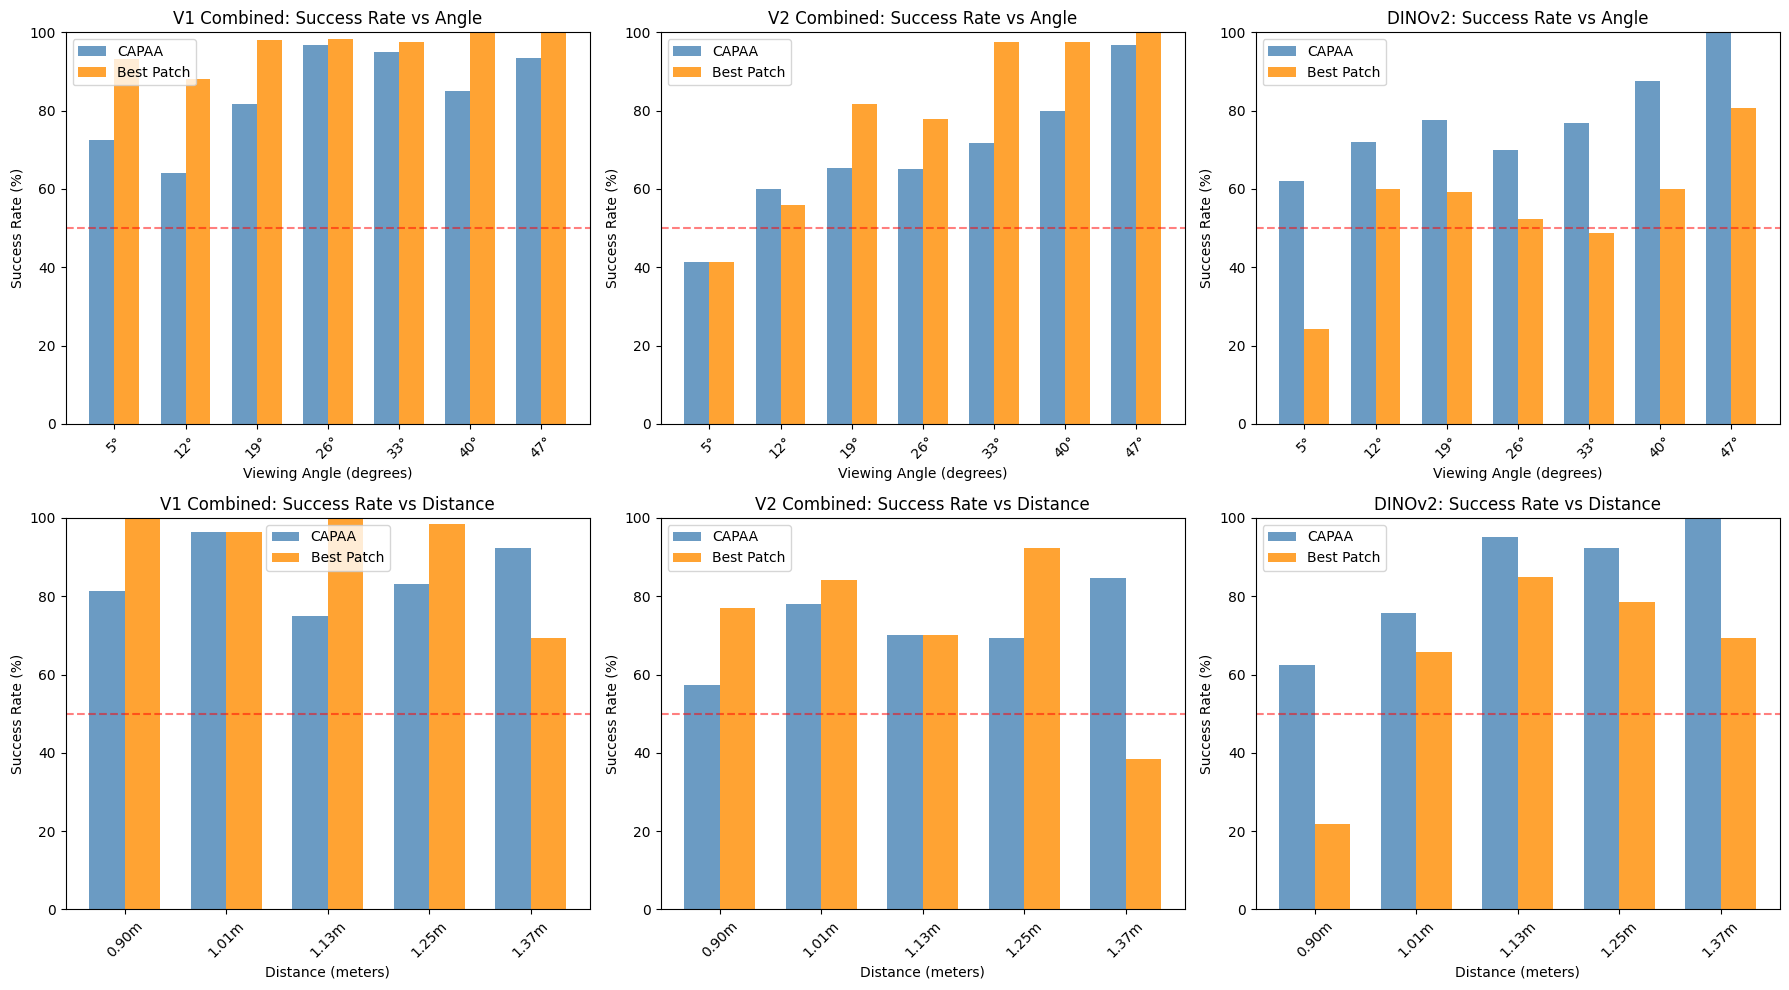

✓ Plot saved to 'comparison_capaa_vs_best_patch.png'


In [58]:
# Visualization: Success rate vs Angle for key models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Key models to compare
models_to_plot = [
    ('v1_combined', 'V1 Combined'),
    ('v2_combined', 'V2 Combined'),
    ('dino', 'DINOv2')
]

# Row 1: Success rate vs Angle
for idx, (model_key, model_name) in enumerate(models_to_plot):
    ax = axes[0, idx]
    
    if model_key == 'dino':
        capaa_col = 'capaa_dino_success'
        bp_col = 'bp_dino_success'
    else:
        capaa_col = f'capaa_{model_key}_success'
        bp_col = f'bp_{model_key}_success'
    
    capaa_by_angle = df.groupby('angle_bin', observed=False)[capaa_col].mean() * 100
    bp_by_angle = df.groupby('angle_bin', observed=False)[bp_col].mean() * 100
    
    x = np.arange(len(angle_mids))
    width = 0.35
    ax.bar(x - width/2, capaa_by_angle.values, width, label='CAPAA', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, bp_by_angle.values, width, label='Best Patch', color='darkorange', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
    ax.set_xlabel('Viewing Angle (degrees)')
    ax.set_ylabel('Success Rate (%)')
    ax.set_title(f'{model_name}: Success Rate vs Angle')
    ax.set_ylim(0, 100)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
    ax.legend()

# Row 2: Success rate vs Distance
for idx, (model_key, model_name) in enumerate(models_to_plot):
    ax = axes[1, idx]
    
    if model_key == 'dino':
        capaa_col = 'capaa_dino_success'
        bp_col = 'bp_dino_success'
    else:
        capaa_col = f'capaa_{model_key}_success'
        bp_col = f'bp_{model_key}_success'
    
    capaa_by_dist = df.groupby('distance_bin', observed=False)[capaa_col].mean() * 100
    bp_by_dist = df.groupby('distance_bin', observed=False)[bp_col].mean() * 100
    
    x = np.arange(len(dist_mids))
    width = 0.35
    ax.bar(x - width/2, capaa_by_dist.values, width, label='CAPAA', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, bp_by_dist.values, width, label='Best Patch', color='darkorange', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{d:.2f}m' for d in dist_mids], rotation=45)
    ax.set_xlabel('Distance (meters)')
    ax.set_ylabel('Success Rate (%)')
    ax.set_title(f'{model_name}: Success Rate vs Distance')
    ax.set_ylim(0, 100)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.savefig('comparison_capaa_vs_best_patch.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to 'comparison_capaa_vs_best_patch.png'")

In [59]:
# Overall Summary
print("="*80)
print("OVERALL SUMMARY")
print("="*80)
print(f"\nTotal paired frames: {len(df)}")
print(f"Angle range: {df['angle_deg'].min():.1f}° to {df['angle_deg'].max():.1f}°")
print(f"Distance range: {df['distance_m'].min():.2f}m to {df['distance_m'].max():.2f}m")

# Count wins
all_comparisons = pd.concat([v1_df, v2_df, dino_df], ignore_index=True)
capaa_wins = (all_comparisons['Winner'] == 'CAPAA').sum()
bp_wins = (all_comparisons['Winner'] == 'Best Patch').sum()
ties = (all_comparisons['Winner'] == 'Tie').sum()

print(f"\n--- Model-by-Model Comparison ---")
print(f"CAPAA wins: {capaa_wins}")
print(f"Best Patch wins: {bp_wins}")
print(f"Ties: {ties}")

# Average success rates across all models
capaa_success_cols = [c for c in df.columns if c.startswith('capaa_') and c.endswith('_success')]
bp_success_cols = [c for c in df.columns if c.startswith('bp_') and c.endswith('_success')]

avg_capaa = df[capaa_success_cols].mean().mean() * 100
avg_bp = df[bp_success_cols].mean().mean() * 100

print(f"\n--- Average Success Rate (All Models) ---")
print(f"CAPAA: {avg_capaa:.1f}%")
print(f"Best Patch: {avg_bp:.1f}%")
print(f"Difference: {avg_capaa - avg_bp:+.1f}%")
print("="*80)

OVERALL SUMMARY

Total paired frames: 277
Angle range: 1.3° to 50.8°
Distance range: 0.84m to 1.43m

--- Model-by-Model Comparison ---
CAPAA wins: 4
Best Patch wins: 7
Ties: 1

--- Average Success Rate (All Models) ---
CAPAA: 74.1%
Best Patch: 78.8%
Difference: -4.7%


In [60]:
# Save results
df.to_csv('comparison_results.csv', index=False)
all_comparisons.to_csv('comparison_summary.csv', index=False)
print("✓ Results saved to 'comparison_results.csv' and 'comparison_summary.csv'")

✓ Results saved to 'comparison_results.csv' and 'comparison_summary.csv'


In [61]:
# Display all comparison tables together
print("\n" + "="*80)
print("ALL COMPARISON TABLES")
print("="*80)
print("\n--- V1 Models ---")
display(v1_df)
print("\n--- V2 Models ---")
display(v2_df)
print("\n--- DINOv2 ---")
display(dino_df)


ALL COMPARISON TABLES

--- V1 Models ---


TypeError: 'str' object is not callable